In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
import pandas as pd
df = pd.read_csv("dataset.csv")
df.head()

,sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies
0,5.1\t3.5\t1.4\t0.2\tsetosa
1,4.9\t3\t1.4\t0.2\tsetosa
2,4.7\t3.2\t1.3\t0.2\tsetosa
3,4.6\t3.1\t1.5\t0.2\tsetosa
4,5\t3.6\t1.4\t0.2\tsetosa


In [3]:
print(df.columns)

Index(['sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies'], dtype='str')


In [4]:
print(df.shape)

(150, 1)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 1 columns):
 #   Column                                                     Non-Null Count  Dtype
---  ------                                                     --------------  -----
 0   sepal_length	sepal_width	petal_length	petal_width	species  150 non-null    str  
dtypes: str(1)
memory usage: 1.3 KB


In [6]:
df.isnull().sum()

sepal_length\tsepal_width\tpetal_length\tpetal_width\tspecies    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(3)

In [ ]:
print(df.columns.tolist())
#print(df.shape)

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [13]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [15]:
X = df[
    ["sepal_length", "sepal_width", "petal_length", "petal_width"]
]
y = df["species"]

In [18]:
print(X.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [19]:
print(y.head())

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [21]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [22]:
print(y_encoded[:10])

[0 0 0 0 0 0 0 0 0 0]


In [23]:
print(encoder.classes_)

['setosa' 'versicolor' 'virginica']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [25]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (120, 4)
X_test : (30, 4)
y_train: (120,)
y_test : (30,)


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
print("First 5 training rows:")
print(X_train_scaled[:5])

First 5 training rows:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


In [30]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (120, 4)
Testing shape: (30, 4)


In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [32]:
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.2917 - loss: 1.0715 - val_accuracy: 0.3333 - val_loss: 1.0810
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3438 - loss: 1.0304 - val_accuracy: 0.3333 - val_loss: 1.0409
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4062 - loss: 0.9903 - val_accuracy: 0.5417 - val_loss: 1.0040
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6562 - loss: 0.9532 - val_accuracy: 0.6667 - val_loss: 0.9682
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7188 - loss: 0.9141 - val_accuracy: 0.7083 - val_loss: 0.9343
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7396 - loss: 0.8783 - val_accuracy: 0.6667 - val_loss: 0.9022
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7812 - loss: 0.8411 - val_accuracy: 0.6667 - val_loss: 0.8716
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8021 - loss: 0.8060 - val_accuracy: 0.6667 - val_loss: 0.8423

In [36]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])
print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.875
Final Validation Accuracy: 0.8333333134651184
Final Training Loss: 0.3023124039173126
Final Validation Loss: 0.35680660605430603


In [37]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Test Accuracy: 0.800000011920929
Test Loss: 0.3610022962093353


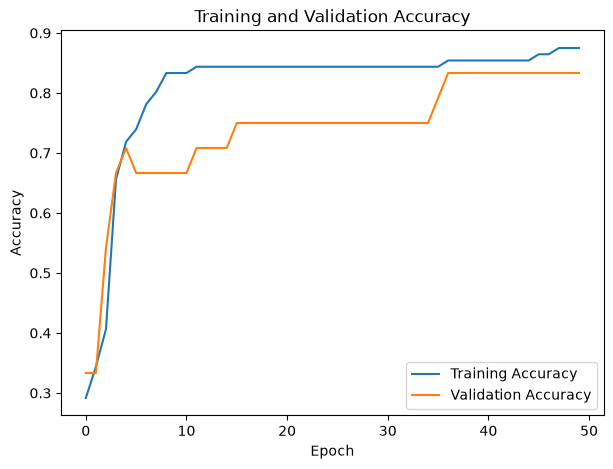

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("accuracy_graph.png")
plt.show()

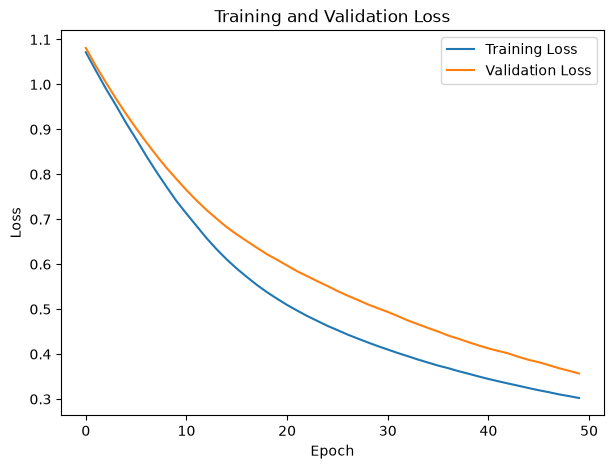

In [39]:
plt.figure(figsize=(7, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("loss_graph.png")
plt.show()

In [40]:
y_pred_prob = model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


In [42]:
y_pred = y_pred_prob.argmax(axis=1)
print(y_pred)

[0 2 1 1 0 2 0 0 2 1 2 2 2 2 0 0 0 1 2 2 0 2 2 2 2 2 2 0 2 0]


In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.40      0.57        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.80        30
   macro avg       0.88      0.80      0.78        30
weighted avg       0.88      0.80      0.78        30



In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  4  6]
 [ 0  0 10]]


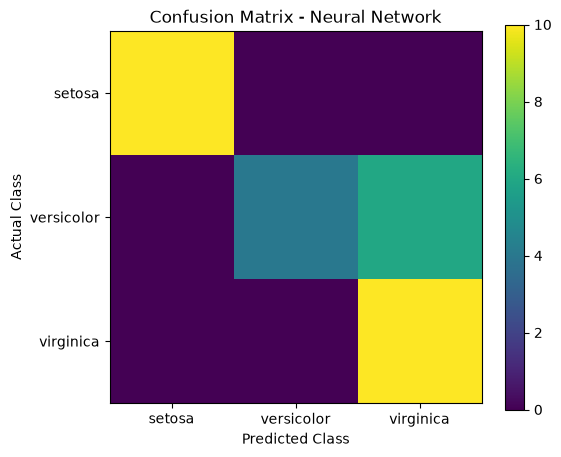

In [45]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(3),
    encoder.classes_
)

plt.yticks(
    range(3),
    encoder.classes_
)

plt.colorbar()

plt.savefig("confusion_matrix.png")
plt.show()

In [46]:
model2 = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

In [47]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

In [48]:
model2.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
history2 = model2.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.2500 - loss: 1.3152 - val_accuracy: 0.3333 - val_loss: 1.2994
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3125 - loss: 1.2576 - val_accuracy: 0.3750 - val_loss: 1.2509
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3438 - loss: 1.2039 - val_accuracy: 0.4583 - val_loss: 1.2094
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3542 - loss: 1.1587 - val_accuracy: 0.3750 - val_loss: 1.1722
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3333 - loss: 1.1165 - val_accuracy: 0.2917 - val_loss: 1.1417
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3542 - loss: 1.0812 - val_accuracy: 0.3333 - val_loss: 1.1153
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3542 - loss: 1.0503 - val_accuracy: 0.3333 - val_loss: 1.0921
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3750 - loss: 1.0225 - val_accuracy: 0.3333 - val_loss: 1.0716

In [50]:
test_loss2, test_accuracy2 = model2.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Model 2 Test Accuracy:", test_accuracy2)
print("Model 2 Test Loss:", test_loss2)

Model 2 Test Accuracy: 0.800000011920929
Model 2 Test Loss: 0.6873645186424255


In [51]:
print("Model 1 Test Accuracy:", test_accuracy)
print("Model 1 Test Loss:", test_loss)

print("Model 2 Test Accuracy:", test_accuracy2)
print("Model 2 Test Loss:", test_loss2)

Model 1 Test Accuracy: 0.800000011920929
Model 1 Test Loss: 0.3610022962093353
Model 2 Test Accuracy: 0.800000011920929
Model 2 Test Loss: 0.6873645186424255


In [54]:
comparison = pd.DataFrame({
    "Model": ["Original Model", "Tuned Model"],
    "Test Accuracy": [test_accuracy, test_accuracy2],
    "Test Loss": [test_loss, test_loss2]
})

comparison
comparison.to_csv("model_comparison.csv",index=False)

In [55]:
model.save("iris_neural_network.keras")